--- ANTRENARE ȘI EVALUARE LOF (eBPF) PE GPU (PyTorch Aliniat) ---
Date partajate cu succes: Train_Normal=25980, Test_Total=13559
Antrenare și Predicție LOF pe GPU...
Procesare finalizată pe GPU în 3.46 secunde!

RAPORT METRICI:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98     11161
        Atac       0.89      0.90      0.90      2398

    accuracy                           0.96     13559
   macro avg       0.94      0.94      0.94     13559
weighted avg       0.96      0.96      0.96     13559

Scor AUC: 0.9823


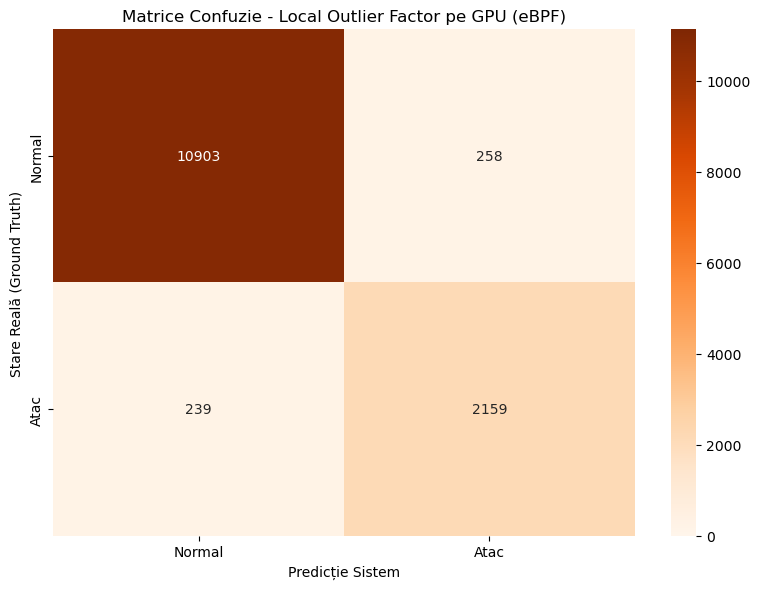

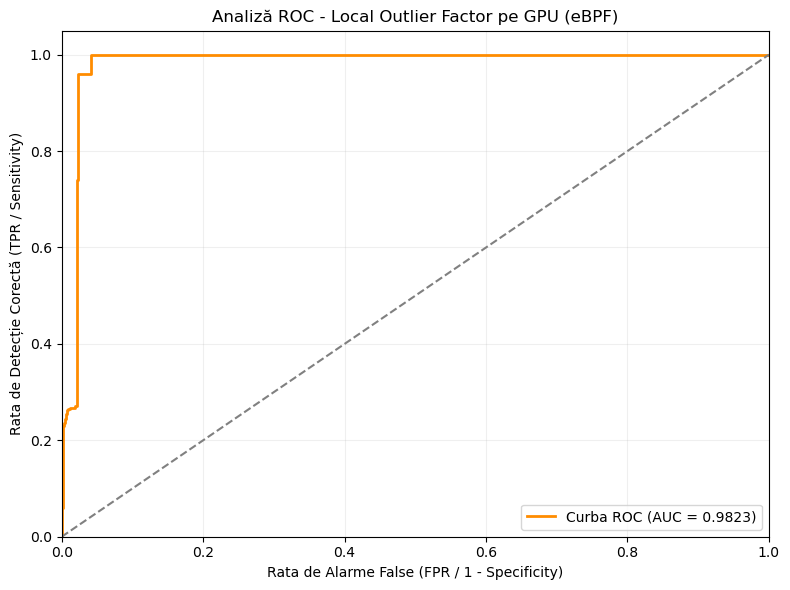


Toate rezultatele și graficele au fost salvate în: D:\disertatie\eBPF_WSL\rezultate_eBPF\LOF


In [ ]:
import pandas as pd
import numpy as np
import torch
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\LOF'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ȘI EVALUARE LOF (eBPF) PE GPU (PyTorch Aliniat) ---")
df = pd.read_csv(dataset_path)

X_raw_np = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y_raw_np = df['label'].values

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train_np = X_raw_np[train_indices][y_raw_np[train_indices] == 0]
X_test_np = X_raw_np[test_indices]
y_test_np = y_raw_np[test_indices]

rng = np.random.default_rng(42)
X_train_np = X_train_np + rng.normal(0, 1e-5, size=X_train_np.shape)
X_test_np = X_test_np + rng.normal(0, 1e-5, size=X_test_np.shape)

X_train_unscaled = torch.tensor(X_train_np, dtype=torch.float32, device=device)
X_test_unscaled = torch.tensor(X_test_np, dtype=torch.float32, device=device)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.long, device=device)

print(f"Date partajate cu succes: Train_Normal={X_train_unscaled.shape[0]}, Test_Total={X_test_unscaled.shape[0]}")

mean = X_train_unscaled.mean(dim=0)
std = X_train_unscaled.std(dim=0)
std[std == 0] = 1.0

X_train = (X_train_unscaled - mean) / std
X_test = (X_test_unscaled - mean) / std

num_samples = len(df)
computed_contamination = np.sum(y_raw_np == 1) / num_samples
optimized_contamination = float(computed_contamination * 0.5)

def compute_stable_k_distances(X_target, X_ref, k):
    dist_matrix = torch.cdist(X_target, X_ref, p=2)
    dist_matrix = torch.round(dist_matrix * 1000000) / 1000000
    k_distances, k_indices = torch.topk(dist_matrix, k, largest=False, sorted=True)
    return k_distances, k_indices, dist_matrix

def fit_predict_lof_gpu(X_train, X_test, k, contamination):
    train_k_dist, train_k_idx, train_dist_mat = compute_stable_k_distances(X_train, X_train, k + 1)
    train_k_distances = train_k_dist[:, -1]
    
    actual_dists = train_dist_mat
    k_dists_rows = train_k_distances.repeat(X_train.shape[0], 1)
    reach_dists = torch.max(k_dists_rows, actual_dists)
    
    lrd_train = 1.0 / (torch.gather(reach_dists, 1, train_k_idx[:, 1:])).mean(dim=1).clamp(min=1e-10)
    lrd_train = torch.nan_to_num(lrd_train, nan=0.0, posinf=0.0)

    test_k_dist, test_k_idx, test_dist_mat = compute_stable_k_distances(X_test, X_train, k)
    
    k_dists_train_matrix = train_k_distances.repeat(X_test.shape[0], 1)
    reach_dists_test = torch.max(k_dists_train_matrix, test_dist_mat)
    
    lrd_test = 1.0 / (torch.gather(reach_dists_test, 1, test_k_idx)).mean(dim=1).clamp(min=1e-10)
    lrd_test = torch.nan_to_num(lrd_test, nan=0.0, posinf=0.0)
    
    lrd_train_neighbors = lrd_train[test_k_idx]
    lof_scores = (lrd_train_neighbors / lrd_test.unsqueeze(1)).mean(dim=1)
    lof_scores = torch.nan_to_num(lof_scores, nan=1.0)
    
    decision_scores = - (lof_scores - 1.0)
    
    threshold = torch.quantile(decision_scores, contamination * 2.0)
    y_pred = torch.where(decision_scores < threshold, 1, 0)
    
    return decision_scores, y_pred

torch.cuda.synchronize()
start_time = time.time()
print("Antrenare și Predicție LOF pe GPU...")

decision_scores_gpu, y_pred_gpu = fit_predict_lof_gpu(X_train, X_test, k=60, contamination=optimized_contamination)

torch.cuda.synchronize()
train_time = time.time() - start_time
print(f"Procesare finalizată pe GPU în {train_time:.2f} secunde!")

y_test = y_test_tensor.cpu().numpy()
y_pred = y_pred_gpu.cpu().numpy()
y_scores = (-decision_scores_gpu.cpu().numpy())

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])
print("\nRAPORT METRICI:")
print(report)
print(f"Scor AUC: {roc_auc:.4f}")

with open(os.path.join(rezultate_path, 'raport_ebpf_lof_gpu.txt'), 'w') as f:
    f.write(f"REZULTATE EBPF LOCAL OUTLIER FACTOR PE GPU\nAUC: {roc_auc:.4f}\nTimp Execuție GPU: {train_time:.2f}s\n\n{report}")

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', vmin=0, vmax=11134, xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - Local Outlier Factor pe GPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_lof_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR / Sensitivity)')
plt.xlabel('Rata de Alarme False (FPR / 1 - Specificity)')
plt.title('Analiză ROC - Local Outlier Factor pe GPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_lof_gpu.png'), dpi=300)
plt.show()

print(f"\nToate rezultatele și graficele au fost salvate în: {rezultate_path}")